# Qwen3 from scratch
... nothing much, was just fascinated by the [technical report published by Qwen3](https://arxiv.org/abs/2505.09388) and thought to build the model from scratch...

### Qwen3 Model Family
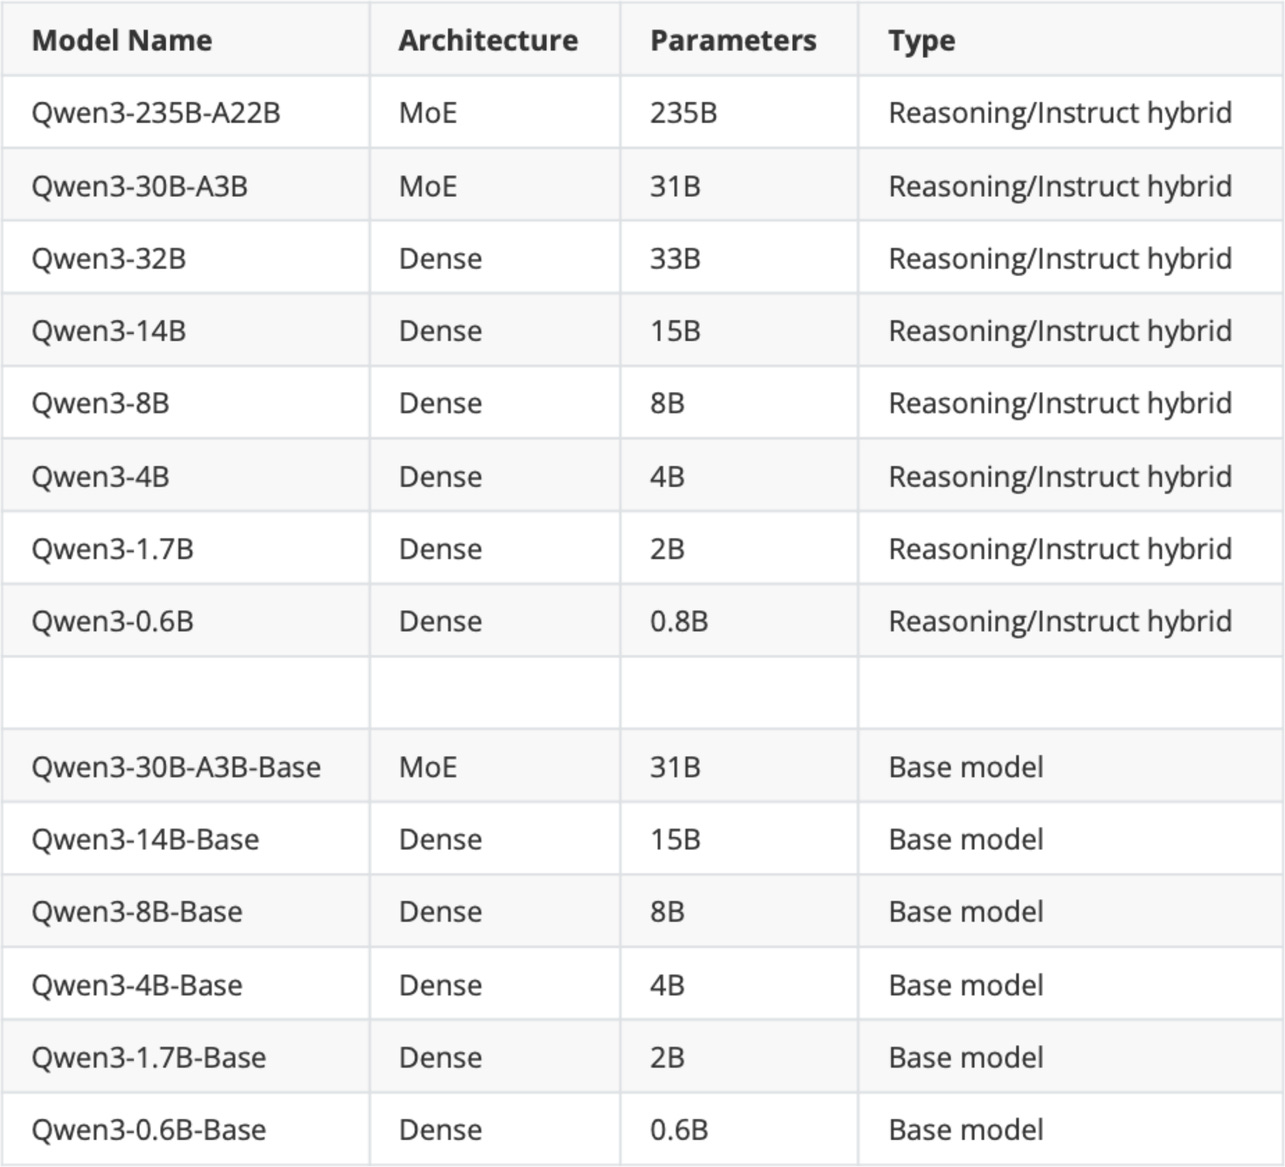
<i>The original Qwen3 model suite released in May 2025. </i>

- "MoE" is Mixture-of-Experts, and "Dense" is the regular, non-MoE models;
- "Base" means pre-trained (but not fine-tuned) base model;
- "Reasoning/Instruct hybrid" means that the model can be either used as a Chain-of-Thought (CoT)-style reasoning model or a regular instruction-following model

Later in July a week after Kimi K2 release, the Qwen3 team updated some of its models

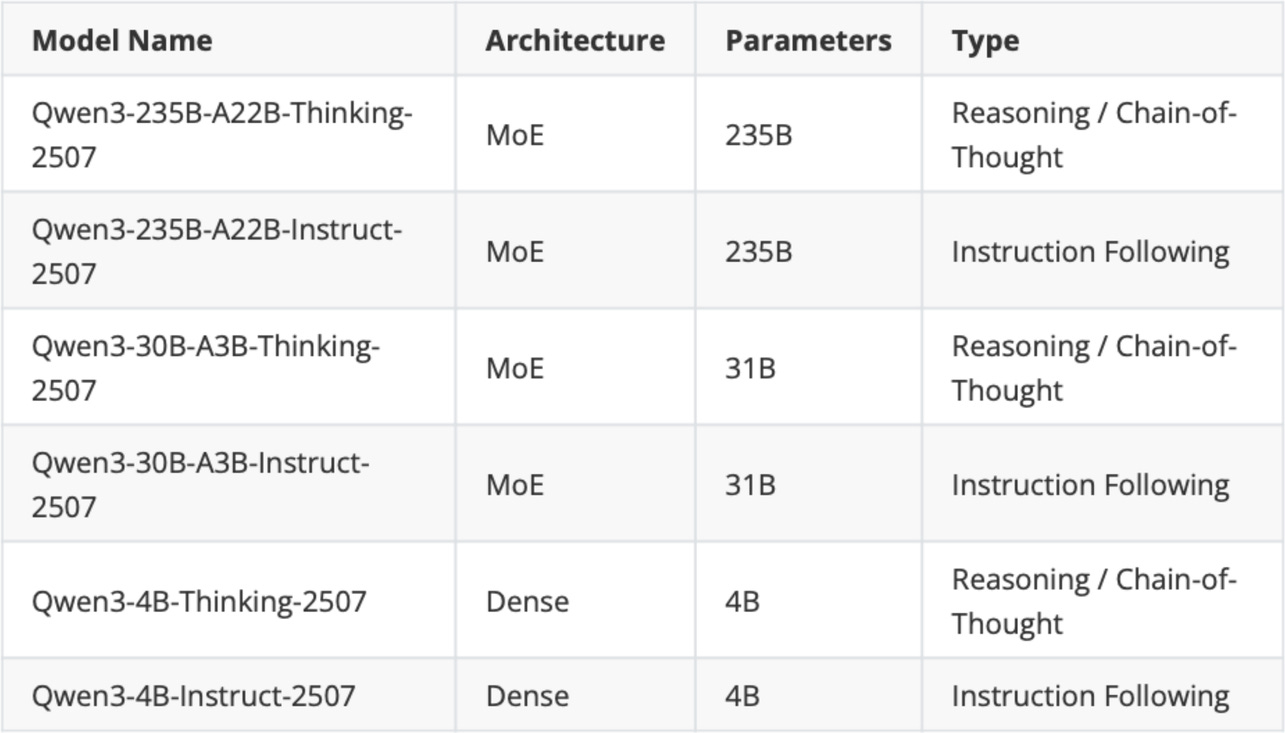

On September 5th, Qwen3 released a [1T parameter “max” instruct variant](https://x.com/Alibaba_Qwen/status/1963991502440562976) that beats Kimi K2, DeepSeek 3.1, and Claude Opus 4 on all major benchmarks.

## Pre and Post Training

I have summarised the pre and post training stages with EVALS from the **technical report** [![arXiv](https://img.shields.io/badge/arXiv-2505.09388-b31b1b.svg?style=for-the-badge)](https://arxiv.org/pdf/2505.09388). Remember to read the details on each stages from the report...

![stages](../_asset/scratch/qwen/stages.png)

Note: that the steps correspond to the Qwen3 base and hybrid models released in May. There was no separate paper for the separate reasoning and instruct variants released in July.

Overall, the pre-training stages looks fairly standard. The interesting aspect here is that in Stage 2, the Qwen3 team explicitly included knowledge-intensive (chain-of-thought-style) data, which is said to enhance reasoning capabilities later on - this would result into base models exhibiting some reasoning behavior already...

**Post Training** pipeline looks very similar to DeepSeek R1...
- Stage 1: Supervised fine-tuning on chain-of-thought data
- Stage 2: Reinforcement learning with verifiable rewards
- Stage 3: more supervised fine-tuning (this time including general, non-reasoning data to support the reasoning/instruct hybrid behavior)
- Stage 4: General-domain reinforcement learning



## Architecture Qwen3

Qwen3 is build on the decoder submodule of the [original transformer architecture] [![arXiv](https://img.shields.io/badge/arXiv-1706.03762-b31b1b.svg?style=for-the-badge)](https://arxiv.org/pdf/1706.03762) - but with a few changes. The model consists of a token embedding layer followed by 28 transformer blocks (for smaller model variants), each containing RMSNorm, RoPE, QKNorm, masked grouped-query attention with `N` heads (e.g. 16, 32 etc), and a feed-forward module with an intermediate size of `d_hidden` (eg. 3,072).

![arch](../_asset/scratch/qwen/qwen3_arch.gif)

## Root Mean Square Normalization

Qwen3 performs RMSNorm (1) before grouped-query attention(GQA) (2) before feed-forward (SwiGLU MLP) (3) Final RMSNorm before LM head

RMSNorm fulfills the same core function as LayerNorm: normalizing layer activations to stabilize and improve training. However, it simplifies the computation by removing the mean-centering step. This means that activations will still be normalized, but they are not centered at 0

<i>a bit of recap on normalization..</i>

> ⚠️ deep nets (especially transformers) get numerically and statistically wild as they stack many layers. Norm layers keep activation in a sane range so training stays stable and gradients keep flowing.

> ⚠️ Without normalization, each layer can amplify or shrink values a bit; after dozens of layers you can get exploding/vanishing activations.

**RMSNorm without learned scale/bias**

$$
\text{RMSNorm}(x)=\frac{x}{\text{rms}(x)}
$$

$$
\text{rms}(x)={\sqrt{\frac{1}{d}\sum_{i=1}^d x_i^2+\epsilon}}
$$

#### Simple numeric example
Let hidden size (d=4). Take one token vector:

$$
(h = [2, 1, 0, 0])
$$

RMS:

$$
\text{rms}(h)=\sqrt{\frac{4+1+0+0}{4}}=\sqrt{1.25}=1.118
$$

$$
\hat h = \text{RMSNorm}(h) = [\frac{2}{1.118},\frac{1}{1.118},\ 0,\ 0] \
$$

$$
\hat h = [1.789,\ 0.894,\ 0,\ 0]
$$

Now imagine training drift scales this token by **10×**:

$$
(h' = 10.h = [20,10,0,0])
$$

$$
\text{rms}(h') = 10\cdot 1.118,\quad = 11.18
$$

$$
\text{RMSNorm}(h') = [1.789,\ 0.894,\ 0,\ 0] \ (\text{same})
$$

============== `Qwen3's RMSNorm` ==============

In [6]:
import torch.nn as nn

class RMSNorm(nn.Module):
    def __init__(
        self,
        emb_dim,
        eps=1e-6,
        bias=False,
        qwen3_compatible=True,
    ):
        super().__init__()
        self.eps = eps
        self.qwen3_compatible = qwen3_compatible
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = (
            nn.Parameter(torch.zeros(emb_dim)) if bias
            else None
        )

    def forward(self, x):
        input_dtype = x.dtype

        if self.qwen3_compatible:
            x = x.to(torch.float32)

        variance = x.pow(2).mean(dim=-1, keepdim=True)
        norm_x = x * torch.rsqrt(variance + self.eps)
        norm_x = norm_x * self.scale

        if self.shift is not None:
            norm_x = norm_x + self.shift

        return norm_x.to(input_dtype)


#### Example
Lets consider one training example where the normalization is applied to the vector consisting of 6 features i.e. 6-D output

In [19]:
import torch
torch.set_printoptions(precision=2, sci_mode=False)

x = torch.tensor([[5.61, 14.32, 0.00, 34.88, 38.70, 11.29]], dtype=torch.float32)

rms = RMSNorm(emb_dim=6, eps=1e-6, bias=False, qwen3_compatible=True)

y_rms = rms(x)

def stats(t):
    mean = t.mean(dim=-1).item()
    var  = t.var(dim=-1, unbiased=False).item()
    return f"{mean:.3f}", f"{var:.3f}"

raw_mean, raw_var = stats(x)
rms_mean, rms_var = stats(y_rms)

print("Input x:", x.squeeze().tolist())
print(f"Input mean={stats(x)}")
print()

print("RMSNorm output:", [round(v, 2) for v in y_rms.squeeze().tolist()])
print(f"RMSNorm mean={stats(y_rms)}")
print()

Input x: [5.610000133514404, 14.319999694824219, 0.0, 34.880001068115234, 38.70000076293945, 11.289999961853027]
Input mean=('17.467', '207.966')

RMSNorm output: [0.25, 0.63, 0.0, 1.54, 1.71, 0.5]
RMSNorm mean=('0.771', '0.405')



#### ... using PyTorch out of box norm functions

In [ ]:
pytorch_rms = nn.RMSNorm(6, eps=1e-6, elementwise_affine=False)
pytorch_ln  = nn.LayerNorm(6, eps=1e-6, elementwise_affine=False)

y_pytorch_ln = pytorch_ln(x)
y_pytorch_rms = pytorch_rms(x)

print("Input:", x)
print("Input mean/var:", stats(x))
print()

print("Torch LayerNorm:", y_pytorch_ln)
print("LN mean/var:", stats(y_pytorch_ln))
print()

print("Torch RMSNorm:", y_pytorch_rms)
print("RMS mean/var:", stats(y_pytorch_rms))


Input: tensor([[ 5.61, 14.32,  0.00, 34.88, 38.70, 11.29]])
Input mean/var: ('17.467', '207.966')

Torch LayerNorm: tensor([[-0.82, -0.22, -1.21,  1.21,  1.47, -0.43]])
LN mean/var: ('-0.000', '1.000')

Torch RMSNorm: tensor([[0.25, 0.63, 0.00, 1.54, 1.71, 0.50]])
RMS mean/var: ('0.771', '0.405')


## Feed forward
GPT-2, the feed forward module consists of two fully connected (linear) layers separated by a non-linear activation function. In Qwen3, this module is replaced with a gated linear unit (GLU) variant([ref paper](https://arxiv.org/abs/2002.05202)), which adds a third linear layer and multiplies its output elementwise with the activated output of the second linear layer.

In Qwen3, the fully conected (fc) linear layers in GLU variant (fc1, fc2) is half the size in comparison to standard feed forward e.g. GPT-2

e.g. from Qwen3 0.6B variant
- fc1: 1024 × 3,072 = 3,145,728  
- fc2: 1024 × 3,072 = 3,145,728 
- fc3: 1024 × 3,072 = 3,145,728  
>Total: 3 × 3,145,728 = 9,437,184 parameters

Compares to standard Feed forward i.e. fc1 and fc2 being twice of GLU
- fc1: 1024 × 2×3,072 = 6,291,456  
- fc2: 1024 × 2×3,072 = 6,291,456 
>Total: 2 × 6,291,456 = 12,582,912 parameters

While GLU variants usually have fewer parameters than regular feed forward modules, they perform better. The improvement comes from the additional multiplicative interaction introduced by the gating mechanism, activation(x_fc1) * x_fc2, which increases the model's expressivity. This is similar to how deeper, slimmer networks can outperform shallower, wider ones, given proper training.

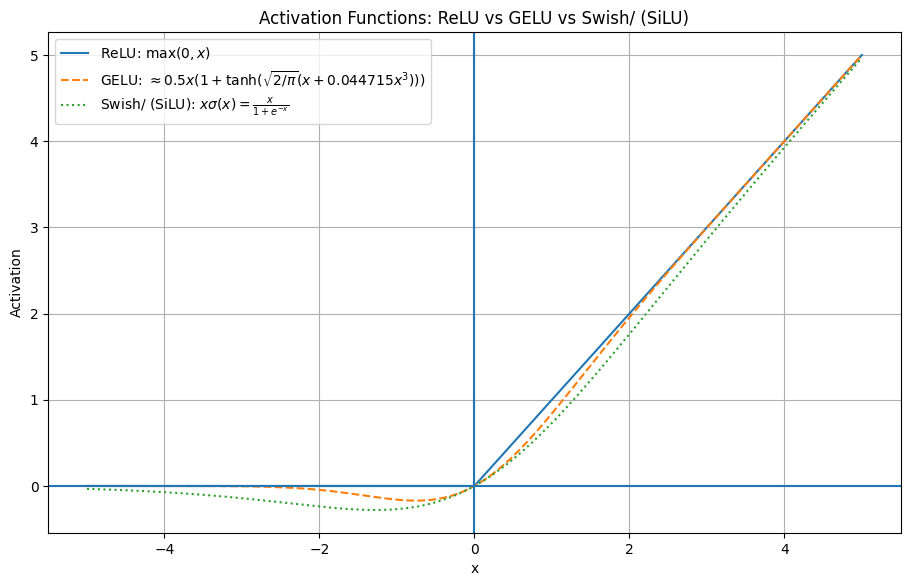

In [25]:
import numpy as np
import matplotlib.pyplot as plt

def relu(x):
    return np.maximum(0, x)

def gelu_tanh(x):
    # GELU tanh approx:
    # 0.5*x*(1 + tanh(sqrt(2/pi) * (x + 0.044715*x^3)))
    return 0.5 * x * (1.0 + np.tanh(np.sqrt(2.0/np.pi) * (x + 0.044715 * x**3)))

# Also known as SiLU
def swish(x):
    # x * sigmoid(x)
    return x / (1.0 + np.exp(-x))

x = np.linspace(-5, 5, 1000)
y_relu = relu(x)
y_gelu = gelu_tanh(x)
y_swish = swish(x)

plt.figure(figsize=(11, 6.5))
plt.plot(x, y_relu, label=r"ReLU: $\max(0, x)$")
plt.plot(x, y_gelu, linestyle="--",
         label=r"GELU: $\approx 0.5x(1+\tanh(\sqrt{2/\pi}(x+0.044715x^3)))$")
plt.plot(x, y_swish, linestyle=":",
         label=r"Swish/ (SiLU): $x\sigma(x)=\frac{x}{1+e^{-x}}$")

plt.axhline(0)
plt.axvline(0)
plt.xlabel("x")
plt.ylabel("Activation")
plt.title("Activation Functions: ReLU vs GELU vs Swish/ (SiLU)")
plt.grid(True)
plt.legend(loc="upper left")
plt.show()


Different activation functions that can be used in a feed forward module (neural network). GELU and SiLU (Swish) offer smooth alternatives to ReLU, which has a sharp kink at input zero. Newer models have largely replaced GELU with the SiLU as it has a similar smoothness, but it is slightly cheaper to compute than GELU and offers comparable modeling performance

============== `Qwen3's feed forward` ============== 

In [7]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.fc1 = nn.Linear(
            cfg["emb_dim"], cfg["hidden_dim"], dtype=cfg["dtype"],
            bias=False
        )
        self.fc2 = nn.Linear(
            cfg["emb_dim"], cfg["hidden_dim"], dtype=cfg["dtype"],
            bias=False
        )
        self.fc3 = nn.Linear(
            cfg["hidden_dim"], cfg["emb_dim"], dtype=cfg["dtype"],
            bias=False
        )

    def forward(self, x):
        x_fc1 = self.fc1(x)
        x_fc2 = self.fc2(x)
        
        # The non-linear activation function here is a SiLU function,           
        # which will be discussed later
        x = nn.functional.silu(x_fc1) * x_fc2
        return self.fc3(x)

## Rotary Position Embeddings (RoPE)
In transformer-based LLMs, positional encoding is necessary because of the attention mechanism. By default, attention treats the input tokens as if they have no order. In the original GPT architecture, absolute positional embeddings addressed this by adding a learned embedding vector for each position in the sequence, which is then added to the token embeddings.

RoPE (rotary position embeddings) introduced a different approach: instead of adding position information as separate embeddings, it encodes position information by rotating the query and key vectors in the attention mechanism in a way that depends on each token's position.

[![arXiv](https://img.shields.io/badge/arXiv-2104.09864-b31b1b.svg?style=for-the-badge)](https://arxiv.org/pdf/2104.09864)



Lets assume Qwen 0.6B single pass with single head and tiny dimension for input **“My name is Qwen”** i.e. positions (0,1,2,3)

* model hidden size $d_{\text{model}}=8$
* single head, so head dim (d_h=8)
* causal mask (like Qwen): token can only attend to itself + earlier tokens
* tokens: (t_0=)“My”, (t_1=)“name”, (t_2=)“is”, (t_3=)“Qwen”
* positions: $(m \in {0,1,2,3})$

Each token has an embedding vector:

$$
e_m \in \mathbb{R}^{d_{\text{model}}}
$$


#### Classical transformer approach...
absolute pos embeddings:

$$
p_m \in \mathbb{R}^{d_{\text{model}}}
$$

and the input to the block is:

$$
x_m = e_m + p_m
$$

**perform Q, K, V projections**

$$
q_m = x_m W_Q,\quad k_m = x_m W_K,\quad v_m = x_m W_V
$$

where $(W_Q,W_K,W_V \in \mathbb{R}^{d_{\text{model}}\times d_h})$

**...and then compute Attention logits**

For query token at position (i) attending to key token at position (j):

$$
\ell_{i,j}=\frac{q_i \cdot k_j}{\sqrt{d_h}} + \text{mask}_{i,j}
$$

**Attention weights and output**

$$
\alpha_{i,:}=\text{softmax}(\ell_{i,:})
$$

$$
o_i=\sum_{j=0}^{T-1}\alpha_{i,j},v_j
$$

**After attention**, the block passes (o) forward (often through output projection + residual + RMSNorm etc).

#### RoPE approach...
In RoPE transformer, there is **no** positional embedding (p_m) added to token embedding.

$$
x_m = e_m
$$

**... and then after perform Q, K, V projections** it rotate Q/K by position, so position affects attention only through the dot product geometry (rotation)

$$
q'_m = R(m)\cdot q_m,\quad k'_m = R(m)\cdot k_m
$$

and then use the rotated q'_m and k'_m to compute attention logits and output...

### Computing R(m)
* head dim (d = 8) (even)
* number of RoPE pairs $(= d/2 = 4)$
* Will assume 6 input tokens ⇒ positions $ (m \in {0,1,2,3,4,5}) $
* base $(\theta = 10000)$ (usual init for theta)

Any head vector (query or key) for one token would look like (for given d):

$$
q = [q_0,q_1,q_2,q_3,q_4,q_5,q_6,q_7]
$$

#### ⚫️ a) **Pair Creation**: RoPE pairs the *first half* with the *second half* (same for Q and K)

> ⚠️ Note: RoPE also uses adjacent pair pattern, but Qwen3 HF code: pairs are (0, D/2), (1, D/2+1), (2, D/2+2)… i.e. it uses classic rotate_half pattern... Refer [rm_adjacent_pattern.ipynb](./rm_adjacent_pattern.ipynb) for details on calculating R(m) using adjacent pattern

Split the vector into two halves:

$$
q_\text{first} = [q_0,q_1,q_2,q_3], \quad
q_\text{second} = [q_4,q_5,q_6,q_7]
$$

Then we form $d/2$ rotation pairs by matching the same index across halves:

* pair 0: $(q_0, q_4)$
* pair 1: $(q_1, q_5)$
* pair 2: $(q_2, q_6)$
* pair 3: $(q_3, q_7)$

This is exactly what `rotate_half(x) = concat(-x2, x1)` implies:
it treats $(q_i, q_{i+d/2})$ as the 2D coordinates to rotate.

#### ⚫️ b) **Compute $ \omega $ (omega)** for each pair `i` i.e. a per-pair frequency (a constant for pair i, same for all tokens)

$$
\omega_i = \theta^{-2i/d}
$$

With 

$$
-2i/d = -i/4 \newline
\theta = 10000 = 10^4 \newline
\omega_i = (10^4)^{-i/4} = 10^{-i}
$$ 

So for each pair `i = (0, 1, 2, 3)`:

* $(\omega_0 = 1)$
* $(\omega_1 = 0.1)$
* $(\omega_2 = 0.01)$
* $(\omega_3 = 0.001)$

In the `rotate_half` implementation you often see the same thing written as:

$$
\text{inv\_freq}_i = \frac{1}{\theta^{(2i)/d}} = \theta^{-2i/d}
$$

because the code typically builds the exponent from `torch.arange(0, d, 2) = [0, 2, 4, ...]`, which is exactly `2i`

In [89]:
import torch
theta = 10000.0
d = 8
i = torch.arange(0, d//2, dtype=torch.float32)  # [0,1,2,3]
omega = theta ** (-2*i/d)
inv_freq = 1 / (theta ** ((2*i)/d))
print("omega:", omega)  
print("inv_freq:", inv_freq)

omega: tensor([1.0000, 0.1000, 0.0100, 0.0010])
inv_freq: tensor([1.0000, 0.1000, 0.0100, 0.0010])


#### ⚫️ c) Calculate rotation angle $\phi_m$ (phi) per input token (denoted by position `m`), per-pair `i`

$$
\phi_{m,i} = m \cdot \omega_i
$$

so 6 input tokens ⇒ positions $ (m \in {0,1,2,3,4,5}) $, we get 6 sets of 4 angles.

In [37]:
import torch
omega = torch.tensor([1.0, 0.1, 0.01, 0.001])
for m in range(6):
    phi = m * omega
    print(f"m={m} --> ϕm={[float(f'{x:.2f}') for x in phi.tolist()]}")

m=0 --> ϕm=[0.0, 0.0, 0.0, 0.0]
m=1 --> ϕm=[1.0, 0.1, 0.01, 0.0]
m=2 --> ϕm=[2.0, 0.2, 0.02, 0.0]
m=3 --> ϕm=[3.0, 0.3, 0.03, 0.0]
m=4 --> ϕm=[4.0, 0.4, 0.04, 0.0]
m=5 --> ϕm=[5.0, 0.5, 0.05, 0.01]


#### ⚫️ d) Build a 2x2 rotation block for one pair in $q_{(m)}$ and angle $\phi_m$

**one token at position (m)** has a query vector:

$$
q^{(m)} = [q^{(m)}_0, q^{(m)}_1, q^{(m)}_2, q^{(m)}_3, q^{(m)}_4, q^{(m)}_5, q^{(m)}_6, q^{(m)}_7] \in \mathbb{R}^8
$$

RoPE produces the rotated query:

$$
\tilde{q}^{(m)} = R(m) \cdot q^{(m)}
$$

For the **half-rotation** layout, the rotation happens on pairs:

$$
(q^{(m)}_i,\; q^{(m)}_{i + d/2}) \quad \text{for } i \in \{0,1,2,3\}
$$

So each pair uses the standard 2D rotation matrix with its own angle $\phi_{m,i}$:

**Example (pair 0 uses indices 0 and 4):**

$$
\begin{bmatrix}
\tilde{q}^{(m)}_0 \\
\tilde{q}^{(m)}_4
\end{bmatrix}
=
\begin{bmatrix}
\cos\phi_{m,0} & -\sin\phi_{m,0} \\
\sin\phi_{m,0} & \cos\phi_{m,0}
\end{bmatrix}
\begin{bmatrix}
q^{(m)}_0 \\
q^{(m)}_4
\end{bmatrix}
$$

Similarly:
* pair 1 rotates indices (1,5) using $\phi_{m,1}$
* pair 2 rotates indices (2,6) using $\phi_{m,2}$
* pair 3 rotates indices (3,7) using $\phi_{m,3}$

**Pair 0 (indices 0,4): $(q^{(m)}_0, q^{(m)}_4)$ with angle $\phi_{m,0}$**

$$
\tilde{q}^{(m)}_0 = q^{(m)}_0 \cos(\phi_{m,0}) - q^{(m)}_4 \sin(\phi_{m,0}) \newline
\tilde{q}^{(m)}_4 = q^{(m)}_0 \sin(\phi_{m,0}) + q^{(m)}_4 \cos(\phi_{m,0})
$$

**Pair 1 (indices 1,5): $(q^{(m)}_1, q^{(m)}_5)$ with angle $\phi_{m,1}$**

$$
\tilde{q}^{(m)}_1 = q^{(m)}_1 \cos(\phi_{m,1}) - q^{(m)}_5 \sin(\phi_{m,1}) \newline
\tilde{q}^{(m)}_5 = q^{(m)}_1 \sin(\phi_{m,1}) + q^{(m)}_5 \cos(\phi_{m,1})
$$

**Pair 2 (indices 2,6): $(q^{(m)}_2, q^{(m)}_6)$ with angle $\phi_{m,2}$**

$$
\tilde{q}^{(m)}_2 = q^{(m)}_2 \cos(\phi_{m,2}) - q^{(m)}_6 \sin(\phi_{m,2}) \newline
\tilde{q}^{(m)}_6 = q^{(m)}_2 \sin(\phi_{m,2}) + q^{(m)}_6 \cos(\phi_{m,2})
$$

**Pair 3 (indices 3,7): $(q^{(m)}_3, q^{(m)}_7)$ with angle $\phi_{m,3}$**

$$
\tilde{q}^{(m)}_3 = q^{(m)}_3 \cos(\phi_{m,3}) - q^{(m)}_7 \sin(\phi_{m,3}) \newline
\tilde{q}^{(m)}_7 = q^{(m)}_3 \sin(\phi_{m,3}) + q^{(m)}_7 \cos(\phi_{m,3})
$$

So, the full $R(m)$ matrix is sparse and couples $(0,4)$, $(1,5)$, $(2,6)$, $(3,7)$ (instead of adjacent blocks):

$$
R(m)=
\begin{bmatrix}
\cos\phi_{m,0} & 0 & 0 & 0 & -\sin\phi_{m,0} & 0 & 0 & 0 \newline
0 & \cos\phi_{m,1} & 0 & 0 & 0 & -\sin\phi_{m,1} & 0 & 0 \newline
0 & 0 & \cos\phi_{m,2} & 0 & 0 & 0 & -\sin\phi_{m,2} & 0 \newline
0 & 0 & 0 & \cos\phi_{m,3} & 0 & 0 & 0 & -\sin\phi_{m,3} \newline
\sin\phi_{m,0} & 0 & 0 & 0 & \cos\phi_{m,0} & 0 & 0 & 0 \newline
0 & \sin\phi_{m,1} & 0 & 0 & 0 & \cos\phi_{m,1} & 0 & 0 \newline
0 & 0 & \sin\phi_{m,2} & 0 & 0 & 0 & \cos\phi_{m,2} & 0 \newline
0 & 0 & 0 & \sin\phi_{m,3} & 0 & 0 & 0 & \cos\phi_{m,3}
\end{bmatrix}
$$

e.g. Rotate $q$ for single token at position m=5

In [90]:
import torch

def rope_omega(d=8, theta=10000.0):
    # Same ω schedule for both adjacent-pair and half-rotation patterns
    i = torch.arange(0, d//2, dtype=torch.float32)  # [0,1,2,3]
    return theta ** (-2*i/d)

def rope_rotate_q(q, m, theta=10000.0):
    # q: shape (d,)
    d = q.shape[-1]
    assert d % 2 == 0, "d must be even"
    d2 = d // 2

    omega = rope_omega(d, theta).to(q.device)   # (d/2,)
    phi = m * omega                              # (d/2,)
    cos, sin = torch.cos(phi), torch.sin(phi)    # (d/2,)

    # Half-rotation / rotate-half layout:
    # pair i is (i, i + d/2)
    q1 = q[:d2]          # indices 0..d/2-1
    q2 = q[d2:]          # indices d/2..d-1

    q1_tilde = q1 * cos - q2 * sin
    q2_tilde = q1 * sin + q2 * cos

    q_tilde = torch.cat([q1_tilde, q2_tilde], dim=-1)

    return q_tilde, phi

q = torch.tensor([1.,2.,3.,4.,5.,6.,7.,8.])
q_tilde, phi = rope_rotate_q(q, m=5)
print("phi:", phi)
print("q:", q)
print("q_tilde:", q_tilde)


phi: tensor([5.0000, 0.5000, 0.0500, 0.0050])
q: tensor([1., 2., 3., 4., 5., 6., 7., 8.])
q_tilde: tensor([ 5.0783, -1.1214,  2.6464,  3.9600,  0.4594,  6.2243,  7.1412,  8.0199])


#### ⚫️ e) Lastly we formulate the full $R(m)$ matrix for (d=8) i.e. 8x8

Define $R(m)\in\mathbb{R}^{8\times 8}$ such that:

$$
\tilde{q}^{(m)} = R(m) \cdot q^{(m)}
$$

For **half-rotation**, $R(m)$ contains four independent 2×2 rotations, but they are *interleaved* in the original coordinate order:

* indices (0,4) use $\phi_{m,0}$
* indices (1,5) use $\phi_{m,1}$
* indices (2,6) use $\phi_{m,2}$
* indices (3,7) use $\phi_{m,3}$

So explicitly, $R(m)$ is:

$$
R(m)=
\begin{bmatrix}
\cos\phi_{m,0} & 0 & 0 & 0 & -\sin\phi_{m,0} & 0 & 0 & 0 \newline
0 & \cos\phi_{m,1} & 0 & 0 & 0 & -\sin\phi_{m,1} & 0 & 0 \newline
0 & 0 & \cos\phi_{m,2} & 0 & 0 & 0 & -\sin\phi_{m,2} & 0 \newline
0 & 0 & 0 & \cos\phi_{m,3} & 0 & 0 & 0 & -\sin\phi_{m,3} \newline
\sin\phi_{m,0} & 0 & 0 & 0 & \cos\phi_{m,0} & 0 & 0 & 0 \newline
0 & \sin\phi_{m,1} & 0 & 0 & 0 & \cos\phi_{m,1} & 0 & 0 \newline
0 & 0 & \sin\phi_{m,2} & 0 & 0 & 0 & \cos\phi_{m,2} & 0 \newline
0 & 0 & 0 & \sin\phi_{m,3} & 0 & 0 & 0 & \cos\phi_{m,3}
\end{bmatrix}
$$

> (Geometric note) If you *reorder* coordinates as $[0,4,1,5,2,6,3,7]$, this matrix becomes block-diagonal with four 2×2 blocks. In HF code, we avoid building $R(m)$ explicitly and apply the same effect with `rotate_half`.

**Derivative w.r.t q (full)**

Since $\tilde{q}^{(m)} = R(m) \cdot q^{(m)}$:

$$
\frac{\partial \tilde{q}^{(m)}}{\partial q^{(m)}} = R(m)
$$

⚠️ For a given token at m=5, prove that the matrix form (geometric view) $R(m) \cdot q^{(m)}$ IS EQUAL to pairwise rotations.

For $d=8$ and $\theta=10000$ we already have:

$$
\omega = [1,\;0.1,\;0.01,\;0.001]
$$

So at token position $m=5$:

$$
\phi_{5,i} = 5\cdot \omega_i
= [5,\;0.5,\;0.05,\;0.005]
$$

Now apply the **pairwise** half-rotation rule (each pair is $(i, i+d/2)$):

* pair 0 rotates $(q_0, q_4)$ by $\phi_{5,0}$
* pair 1 rotates $(q_1, q_5)$ by $\phi_{5,1}$
* pair 2 rotates $(q_2, q_6)$ by $\phi_{5,2}$
* pair 3 rotates $(q_3, q_7)$ by $\phi_{5,3}$

That yields:

$$
\tilde{q}^{(5)}_0 = q^{(5)}_0 \cos(5) - q^{(5)}_4 \sin(5) \\
\tilde{q}^{(5)}_4 = q^{(5)}_0 \sin(5) + q^{(5)}_4 \cos(5)
$$

and similarly for $(1,5)$ with angle $0.5$, $(2,6)$ with $0.05$, $(3,7)$ with $0.005$.

If you write those four 2D rotations into a single linear map over $\mathbb{R}^8$, you get the 8×8 matrix $R(5)$ from the previous section — i.e.:

$$
\tilde{q}^{(5)} = R(5)\, q^{(5)}
$$

So the “matrix form” is a glorified way of stacking the four independent 2D rotations into one big linear operator.


In [93]:
import torch

def build_Rm(m, d=8, theta=10000.0):
    omega = rope_omega(d, theta)
    phi = m * omega
    cos, sin = torch.cos(phi), torch.sin(phi)

    Rm = torch.zeros(d, d)

    # Half-rotation / rotate-half layout: pair i is (i, i + d/2)
    d2 = d // 2
    for i in range(d2):
        a = i
        b = i + d2
        Rm[a, a] = cos[i]
        Rm[a, b] = -sin[i]
        Rm[b, a] = sin[i]
        Rm[b, b] = cos[i]

    return Rm, phi

# For a single token at position m=5
q = torch.tensor([1.,2.,3.,4.,5.,6.,7.,8.])
Rm, phi = build_Rm(m=5)
q_tilde_mat = Rm @ q

q_tilde_pair, _ = rope_rotate_q(q, m=5)
print("phi:", phi)
print("q:", q)
print("R(m):", Rm)
print("q_tilde (matrix form):", q_tilde_mat)
print("q_tilde (pairwise form):", q_tilde_pair)
print("Difference:", (q_tilde_mat - q_tilde_pair).abs().max().item())

phi: tensor([5.0000, 0.5000, 0.0500, 0.0050])
q: tensor([1., 2., 3., 4., 5., 6., 7., 8.])
R(m): tensor([[ 0.2837,  0.0000,  0.0000,  0.0000,  0.9589,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.8776,  0.0000,  0.0000,  0.0000, -0.4794,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.9988,  0.0000,  0.0000,  0.0000, -0.0500,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  1.0000,  0.0000,  0.0000,  0.0000, -0.0050],
        [-0.9589,  0.0000,  0.0000,  0.0000,  0.2837,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.4794,  0.0000,  0.0000,  0.0000,  0.8776,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0500,  0.0000,  0.0000,  0.0000,  0.9988,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0050,  0.0000,  0.0000,  0.0000,  1.0000]])
q_tilde (matrix form): tensor([ 5.0783, -1.1214,  2.6464,  3.9600,  0.4594,  6.2243,  7.1412,  8.0199])
q_tilde (pairwise form): tensor([ 5.0783, -1.1214,  2.6464,  3.9600,  0.4594,  6.2243,  7.1412,  8.0199])
Difference: 0.0


============== `Qwen3's RoPE function` ============== 

`compute_rope_params(...)`
Precomputes cos and sin tables for all positions up to context_length.

In [116]:
import torch

def compute_rope_params(head_dim, theta_base=10_000, context_length=4096, dtype=torch.float32):
    assert head_dim % 2 == 0, "Embedding dimension must be even"

    # Compute the inverse frequencies
    inv_freq = 1.0 / (theta_base ** (torch.arange(0, head_dim, 2, dtype=dtype)[: (head_dim // 2)].float() / head_dim))

    # Generate position indices
    positions = torch.arange(context_length, dtype=dtype)

    # Compute the angles
    angles = positions.unsqueeze(1) * inv_freq.unsqueeze(0)  # Shape: (context_length, head_dim // 2)

    # Expand angles to match the head_dim
    angles = torch.cat([angles, angles], dim=1)  # Shape: (context_length, head_dim)

    # Precompute sine and cosine
    cos = torch.cos(angles)
    sin = torch.sin(angles)

    return cos, sin, angles

In [117]:
cos, sin, angles = compute_rope_params(
    head_dim=8,
    theta_base=10_000.0,
    context_length=6,
)
print("cos:", cos)
print("sin:", sin)
print("angles:", angles)

cos: tensor([[ 1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000],
        [ 0.5403,  0.9950,  0.9999,  1.0000,  0.5403,  0.9950,  0.9999,  1.0000],
        [-0.4161,  0.9801,  0.9998,  1.0000, -0.4161,  0.9801,  0.9998,  1.0000],
        [-0.9900,  0.9553,  0.9996,  1.0000, -0.9900,  0.9553,  0.9996,  1.0000],
        [-0.6536,  0.9211,  0.9992,  1.0000, -0.6536,  0.9211,  0.9992,  1.0000],
        [ 0.2837,  0.8776,  0.9988,  1.0000,  0.2837,  0.8776,  0.9988,  1.0000]])
sin: tensor([[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.8415,  0.0998,  0.0100,  0.0010,  0.8415,  0.0998,  0.0100,  0.0010],
        [ 0.9093,  0.1987,  0.0200,  0.0020,  0.9093,  0.1987,  0.0200,  0.0020],
        [ 0.1411,  0.2955,  0.0300,  0.0030,  0.1411,  0.2955,  0.0300,  0.0030],
        [-0.7568,  0.3894,  0.0400,  0.0040, -0.7568,  0.3894,  0.0400,  0.0040],
        [-0.9589,  0.4794,  0.0500,  0.0050, -0.9589,  0.4794,  0.0500,  0.0050]])
angl

`apply_rope(x, cos, sin, offset)`
Applies RoPE to Q/K tensor shaped (batch, num of heads,num of tokens, head_dim) i.e. B, H, T, D.

In [118]:
import torch

def apply_rope(x, cos, sin, offset=0):
    # x: (batch_size, num_heads, seq_len, head_dim)
    batch_size, num_heads, seq_len, head_dim = x.shape
    assert head_dim % 2 == 0, "Head dimension must be even"

    # Split x into first half and second half
    x1 = x[..., : head_dim // 2]  # First half
    x2 = x[..., head_dim // 2:]  # Second half

    # Adjust sin and cos shapes
    cos = cos[offset:offset + seq_len, :].unsqueeze(0).unsqueeze(0)  # Shape: (1, 1, seq_len, head_dim)
    sin = sin[offset:offset + seq_len, :].unsqueeze(0).unsqueeze(0)

    # Apply the rotary transformation
    rotated = torch.cat((-x2, x1), dim=-1)
    x_rotated = (x * cos) + (rotated * sin)

    # It's ok to use lower-precision after applying cos and sin rotation
    return x_rotated.to(dtype=x.dtype)

In [119]:
if __name__ == "__main__":
    torch.manual_seed(0)

    BATCH, NUM_HEADS, NUM_TOKENS, D = 2, 3, 6, 8
    x = torch.randn(BATCH, NUM_HEADS, NUM_TOKENS, D)

    cos, sin, angles = compute_rope_params(
        head_dim=D,
        theta_base=10_000.0,
        context_length=NUM_TOKENS,
    )
    y = apply_rope(x, cos, sin, offset=5)

    print("Original Tensor (x) shape:", x.shape)
    print("Rotated Tensor (y) shape:", y.shape)
    print("Tensor [0, 0, 0] before RoPE:", x[0, 0, 0])
    print("Tensor [0, 0, 0] after RoPE:", y[0, 0, 0])

Original Tensor (x) shape: torch.Size([2, 3, 6, 8])
Rotated Tensor (y) shape: torch.Size([2, 3, 6, 8])
Tensor [0, 0, 0] before RoPE: tensor([-1.1258, -1.1524, -0.2506, -0.4339,  0.8487,  0.6920, -0.3160, -2.1152])
Tensor [0, 0, 0] after RoPE: tensor([ 0.4945, -1.3431, -0.2345, -0.4233,  1.3203,  0.0548, -0.3281, -2.1174])


## Grouped Query Attention (GQA)

Grouped query attention (GQA) is more compute- and parameter-efficient alternative to the original multi-head attention (MHA) mechanism. Unlike MHA, where each head also has its own set of keys and values, to reduce memory usage, GQA groups multiple heads to share the same key and value projections. So, the core idea behind GQA is to reduce the number of key and value heads by sharing them across multiple query heads which (1) lowers the model's parameter count and (2) reduces the memory bandwidth usage for key and value tensors during inference since fewer keys and values need to be stored and retrieved from the KV cache. 

Even with less parameters, the paper shows that GQA performs comparably to standard MHA \
[![arXiv](https://img.shields.io/badge/arXiv-2305.13245-b31b1b.svg?style=for-the-badge)](https://arxiv.org/pdf/2305.13245)

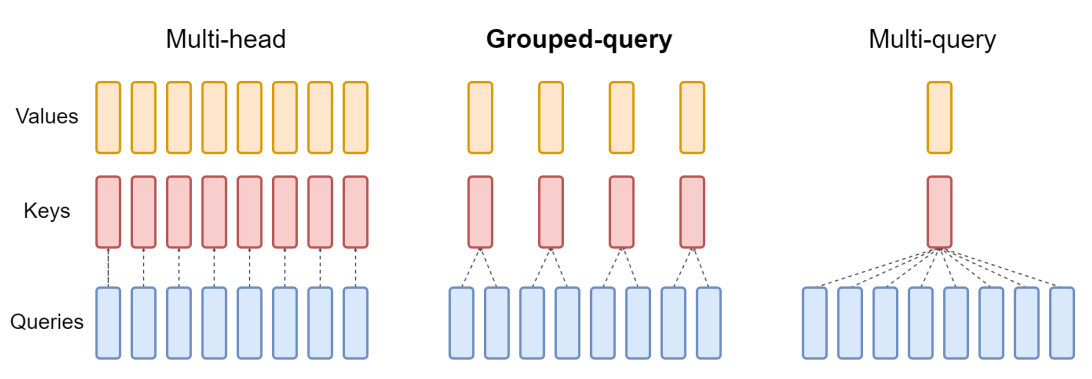

#### Lets break it down for Qwen3 0.6B

* **num_layers** = 28 (transformer blocks)
* **d_in / emb_dim** = 1024
* **num_heads** = 16
* **head_dim** 1024 / 16 = **64**
* **ffn_hidden_dim** = 3072 (not a GQA concern, but is part of each block)

In normal **MHA**:

We would have 16 Q heads, 16 K heads, 16 V heads (all separate).

In **GQA**, lets assume a KV group of 8 (similar to the fig above):

* We will have **16 Q heads**,
* so every **2 Q heads share the same K/V**.

In [98]:
num_heads = 16
num_kv_groups = 8
head_dim = None
d_in = 1024

assert num_heads % num_kv_groups == 0, "num_heads must be divisible by num_kv_groups"

group_size = num_heads // num_kv_groups 

if head_dim is None:
    assert d_in % num_heads == 0, "d_in must be divisible by num_heads when head_dim is None"
    head_dim = d_in // num_heads

d_out = num_heads * head_dim #should be same as d_in

print("Q Heads:", num_heads)
print("KV Heads (num of KV groups):", num_kv_groups)
print("how many Q heads share one KV head?:", group_size)
print("Dim per head:", head_dim)
print("Input Dim:", d_in)
print("Output Dim:", d_out)

Q Heads: 16
KV Heads (num of KV groups): 8
how many Q heads share one KV head?: 2
Dim per head: 64
Input Dim: 1024
Output Dim: 1024


| G (=num_kv_groups) | group_size = H/G | K/V projection dim (G*Dh) |  K/V cache vs MHA |
| -----------------: | ---------------: | ------------------------: | ----------------: |
|                 16 |                1 |              16*64 = 1024 |       same as MHA |
|                  8 |                2 |                8*64 = 512 |        2× smaller |
|                  4 |                4 |                4*64 = 256 |        4× smaller |
|                  2 |                8 |                2*64 = 128 |        8× smaller |
|                  1 |               16 |                 1*64 = 64 | 16× smaller (MQA) |

Q/K/V projection. See how the K/V is 2x smaller with the group size of 2

In [99]:
W_query = nn.Linear(d_in, d_out, bias=False)
W_key   = nn.Linear(d_in, num_kv_groups * head_dim, bias=False)
W_value = nn.Linear(d_in, num_kv_groups * head_dim, bias=False)

print("W_query shape:", W_query.weight.shape)
print("W_key shape:", W_key.weight.shape)
print("W_value shape:", W_value.weight.shape)

W_query shape: torch.Size([1024, 1024])
W_key shape: torch.Size([512, 1024])
W_value shape: torch.Size([512, 1024])


output projection maps back to input dim

In [83]:
out_proj = nn.Linear(d_out, d_in, bias=False)
print("out_proj shape:", out_proj.weight.shape)

out_proj shape: torch.Size([1024, 1024])


RMSNorm on Q and K i.e. before doing dot-product attention, normalize each head vector (length 64) for Q and K.

In [84]:
q_norm = RMSNorm(head_dim, eps=1e-6)
k_norm = RMSNorm(head_dim, eps=1e-6)

Lastly the Forward Pass
- For each token, compute Q with 16 heads and K/V with 8 heads (Projection)

```python
q = self.W_query(x)   
k = self.W_key(x)     
v = self.W_value(x)   
```

- Split the flat projection vectors into multi heads, reorder so "heads" comes before token (which makes the attention math easy)
    - q shape: (BATCH, NUM_TOKENS, NUM_HEADS * HEAD_DIM) = (BATCH, NUM_TOKENS, 16*64)
    - k shape: (BATCH, NUM_TOKENS, KV_HEADs *  HEAD_DIM) = (BATCH, NUM_TOKENS, 8*64)
    - v shape: (BATCH, NUM_TOKENS, KV_HEADs *  HEAD_DIM) = (BATCH, NUM_TOKENS, 8*64)

```python
q = q.view(BATCH, NUM_TOKENS, self.num_heads, self.head_dim).transpose(1, 2) 
k_new = k.view(BATCH, NUM_TOKENS, self.num_kv_groups, self.head_dim).transpose(1, 2) 
v_new = v.view(BATCH, NUM_TOKENS, self.num_kv_groups, self.head_dim).transpose(1, 2)
```

- Apply per-head RMSNorm on Q and K

```python
q = self.q_norm(q)
k_new = self.k_norm(k_new)
```

- RoPE on Q and K (position encoding)

```python
q = apply_rope_adjacent(q, cos, sin, offset=start_pos)
k_new = apply_rope_adjacent(k_new, cos, sin, offset=start_pos)
```

- Cache KV
- Scaled dot-product attention scores

```python
attn_scores = q @ k.transpose(2, 3)
attn_scores = attn_scores.masked_fill(mask, float("-inf"))
attn_weights = torch.softmax(attn_scores / sqrt(Dh), dim=-1)
```

- Weighted sum of values, merge heads back + output projection

```python
ctx = attn_weights @ v
ctx = ctx.transpose(1, 2).contiguous().view(B, T, self.d_out)
out = self.out_proj(ctx)
```


============== `Qwen3's GQA Implementation` ============== 

In [120]:
import torch
import torch.nn as nn

class GroupedQueryAttention(nn.Module):
    """
    GQA: H query heads, but only G key/value heads (KV shared across groups).
    """
    def __init__(self, d_in, num_heads, num_kv_groups, head_dim=None,
                 qk_norm=False, dtype=None):
        super().__init__()
        assert num_heads % num_kv_groups == 0, "num_heads must be divisible by num_kv_groups"

        self.num_heads = num_heads                  
        self.num_kv_groups = num_kv_groups          
        self.group_size = num_heads // num_kv_groups   # how many Q heads share one KV head

        if head_dim is None:
            assert d_in % num_heads == 0, "d_in must be divisible by num_heads when head_dim is None"
            head_dim = d_in // num_heads

        self.head_dim = head_dim                    
        self.d_out = num_heads * head_dim           

        # Q has H heads, so project to H*Dh
        self.W_query = nn.Linear(d_in, self.d_out, bias=False, dtype=dtype)

        # K/V have only G heads, so project to G*Dh (smaller than Q)
        self.W_key   = nn.Linear(d_in, num_kv_groups * head_dim, bias=False, dtype=dtype)
        self.W_value = nn.Linear(d_in, num_kv_groups * head_dim, bias=False, dtype=dtype)

        # Merge heads back to model dim
        self.out_proj = nn.Linear(self.d_out, d_in, bias=False, dtype=dtype)

        # Optional per-head RMSNorm on Q and K (stability trick)
        if qk_norm:
            self.q_norm = RMSNorm(head_dim, eps=1e-6)
            self.k_norm = RMSNorm(head_dim, eps=1e-6)
        else:
            self.q_norm = None
            self.k_norm = None

    def forward(self, x, mask, cos, sin, start_pos=0, cache=None):
        BATCH, NUM_TOKENS, _ = x.shape

        # 1) Projections
        q = self.W_query(x)   
        k = self.W_key(x)     
        v = self.W_value(x)   

        # 2) Split into heads
        q = q.view(BATCH, NUM_TOKENS, self.num_heads, self.head_dim).transpose(1, 2)        
        k_new = k.view(BATCH, NUM_TOKENS, self.num_kv_groups, self.head_dim).transpose(1, 2) 
        v_new = v.view(BATCH, NUM_TOKENS, self.num_kv_groups, self.head_dim).transpose(1, 2)

        # 3) Optional Q/K norm (per head)
        if self.q_norm is not None:
            q = self.q_norm(q)
        if self.k_norm is not None:
            k_new = self.k_norm(k_new)

        # 4) RoPE on Q and K (use offset for decoding)
        q = apply_rope(q, cos, sin, offset=start_pos)
        k_new = apply_rope(k_new, cos, sin, offset=start_pos)

        # 5) KV cache: append along sequence dimension (dim=2)
        if cache is not None:
            prev_k, prev_v = cache                               
            k = torch.cat([prev_k, k_new], dim=2)                
            v = torch.cat([prev_v, v_new], dim=2)                
        else:
            k, v = k_new, v_new                                  

        next_cache = (k, v)

        # 6) Expand KV heads G -> H (KV shared across group_size query heads)
        k = k.repeat_interleave(self.group_size, dim=1)           
        v = v.repeat_interleave(self.group_size, dim=1)           

        # 7) Scaled dot-product attention
        attn_scores = q @ k.transpose(2, 3)                       
        attn_scores = attn_scores.masked_fill(mask, float("-inf"))# mask=True blocks

        attn_weights = torch.softmax(attn_scores / (self.head_dim ** 0.5), dim=-1)  

        # 8) Weighted sum of values
        ctx = attn_weights @ v                                    

        # 9) Merge heads and project out
        ctx = ctx.transpose(1, 2).contiguous().view(BATCH, NUM_TOKENS, self.d_out)  
        out = self.out_proj(ctx)                                  

        return out, next_cache

## Transformer Block

It basically combines GQA and Feed forward together with normalization and repeat it X times e.g. for 0.6B version it would repeat 28 times.

In [101]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = GroupedQueryAttention(
            d_in=cfg["emb_dim"],
            num_heads=cfg["n_heads"],
            head_dim=cfg["head_dim"],
            num_kv_groups=cfg["n_kv_groups"],
            qk_norm=cfg["qk_norm"],
            dtype=cfg["dtype"]
        )
        self.ff = FeedForward(cfg)
        self.norm1 = RMSNorm(cfg["emb_dim"], eps=1e-6)
        self.norm2 = RMSNorm(cfg["emb_dim"], eps=1e-6)

    def forward(self, x, mask, cos, sin, start_pos=0, cache=None):
        shortcut = x
        x = self.norm1(x)
        x, next_cache = self.att(
            x, mask, cos, sin, start_pos=start_pos,cache=cache
        )  # (batch_size, num_tokens, emb_size)
        x = x + shortcut

        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = x + shortcut

        return x, next_cache 

## Qwen3Model Class

In [121]:
class Qwen3Model(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        # Main model parameters
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"],
                                    dtype=cfg["dtype"])

        self.trf_blocks = nn.ModuleList(
            [TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )
        self.final_norm = RMSNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"],
            bias=False, dtype=cfg["dtype"]
        )

        # Reusable utilities
        if cfg["head_dim"] is None:
            head_dim = cfg["emb_dim"] // cfg["n_heads"]
        else:
            head_dim = cfg["head_dim"]
        cos, sin, _ = compute_rope_params(
            head_dim=head_dim,
            theta_base=cfg["rope_base"],
            context_length=cfg["context_length"]
        )
        self.register_buffer("cos", cos, persistent=False)
        self.register_buffer("sin", sin, persistent=False)
        self.cfg = cfg
        self.current_pos = 0  # Track current position in KV cache

    def forward(self, in_idx, cache=None):
        # Forward pass
        tok_embeds = self.tok_emb(in_idx)
        x = tok_embeds

        num_tokens = x.shape[1]
        if cache is not None:
            pos_start = self.current_pos
            pos_end = pos_start + num_tokens
            self.current_pos = pos_end
            mask = torch.triu(
                torch.ones(
                    pos_end, pos_end, device=x.device, dtype=torch.bool
                ),
                diagonal=1
            )[pos_start:pos_end, :pos_end]
        else:
            pos_start = 0  # Not strictly necessary but helps torch.compile
            mask = torch.triu(
                torch.ones(num_tokens, num_tokens, device=x.device,
                           dtype=torch.bool),
                diagonal=1
            )
        # Prefill (no cache): mask starts as (num_tokens, num_tokens)
        # Cached decoding: mask starts as (num_tokens, prev_k_number_tokens + num_tokens)
        #
        # We add two leading dimensions so the mask becomes
        # (1, 1, num_tokens, num_tokens) during prefill and
        # (1, 1, num_tokens, total_key_tokens) during cached decoding.
        # These extra dimensions let PyTorch broadcast the same mask
        # across all batches and attention heads when applying it to
        # attn_scores of shape (batch, num_heads, num_tokens, total_key_tokens).
        mask = mask[None, None, :, :]

        for i, block in enumerate(self.trf_blocks):
            blk_cache = cache.get(i) if cache else None
            x, new_blk_cache = block(x, mask, self.cos, self.sin,
                                     start_pos=pos_start,
                                     cache=blk_cache)
            if cache is not None:
                cache.update(i, new_blk_cache)

        x = self.final_norm(x)
        logits = self.out_head(x.to(self.cfg["dtype"]))
        return logits

    def reset_kv_cache(self):
        self.current_pos = 0

In [122]:
CHOOSE_MODEL = "0.6B"

if CHOOSE_MODEL == "0.6B":
    QWEN3_CONFIG = {
        "vocab_size": 151_936,           # Vocabulary size
        "context_length": 40_960,        # Context length that was used to train the model
        "emb_dim": 1024,                 # Embedding dimension
        "n_heads": 16,                   # Number of attention heads
        "n_layers": 28,                  # Number of layers
        "hidden_dim": 3072,              # Size of the intermediate dimension in FeedForward
        "head_dim": 128,                 # Size of the heads in GQA
        "qk_norm": True,                 # Whether to normalize queries and keys in GQA
        "n_kv_groups": 8,                # Key-Value groups for grouped-query attention
        "rope_base": 1_000_000.0,        # The base in RoPE's "theta"
        "dtype": torch.bfloat16,         # Lower-precision dtype to reduce memory usage
    }
else:
    raise ValueError(f"{CHOOSE_MODEL} is not supported.")

In [123]:
model = Qwen3Model(QWEN3_CONFIG)

I downloaded the safetensors for Qwen3-0.6B. Its basically a state_dict saved to disck showing tensor names (weights) that we would load

In [105]:
from safetensors.torch import safe_open

with safe_open("model/model.safetensors", framework="pt", device="cpu") as f:
    for k in list(f.keys())[:50]:
        print(k, f.get_tensor(k).shape)

lm_head.weight torch.Size([151936, 1024])
model.embed_tokens.weight torch.Size([151936, 1024])
model.layers.0.input_layernorm.weight torch.Size([1024])
model.layers.0.mlp.down_proj.weight torch.Size([1024, 3072])
model.layers.0.mlp.gate_proj.weight torch.Size([3072, 1024])
model.layers.0.mlp.up_proj.weight torch.Size([3072, 1024])
model.layers.0.post_attention_layernorm.weight torch.Size([1024])
model.layers.0.self_attn.k_norm.weight torch.Size([128])
model.layers.0.self_attn.k_proj.weight torch.Size([1024, 1024])
model.layers.0.self_attn.o_proj.weight torch.Size([1024, 2048])
model.layers.0.self_attn.q_norm.weight torch.Size([128])
model.layers.0.self_attn.q_proj.weight torch.Size([2048, 1024])
model.layers.0.self_attn.v_proj.weight torch.Size([1024, 1024])
model.layers.1.input_layernorm.weight torch.Size([1024])
model.layers.1.mlp.down_proj.weight torch.Size([1024, 3072])
model.layers.1.mlp.gate_proj.weight torch.Size([3072, 1024])
model.layers.1.mlp.up_proj.weight torch.Size([3072, 

##### Function to load the weights into Qwen3Model model object

In [124]:
def load_weights_into_qwen(model, param_config, params):
    def assign(left, right, tensor_name="unknown"):
        if left.shape != right.shape:
            raise ValueError(
                f"Shape mismatch in tensor "
                f"'{tensor_name}'. Left: {left.shape}, "
                f"Right: {right.shape}"
            )
        return torch.nn.Parameter(
            right.clone().detach()
            if isinstance(right, torch.Tensor)
            else torch.tensor(right)
        )

    model.tok_emb.weight = assign(
        model.tok_emb.weight,
        params["model.embed_tokens.weight"],
        "model.embed_tokens.weight"
    )

    for l in range(param_config["n_layers"]):
        block = model.trf_blocks[l]
        att = block.att

        # Q, K, V projections (weights)
        att.W_query.weight = assign(
            att.W_query.weight,
            params[f"model.layers.{l}.self_attn.q_proj.weight"],
            f"model.layers.{l}.self_attn.q_proj.weight"
        )
        att.W_key.weight = assign(
            att.W_key.weight,
            params[f"model.layers.{l}.self_attn.k_proj.weight"],
            f"model.layers.{l}.self_attn.k_proj.weight"
        )
        att.W_value.weight = assign(
            att.W_value.weight,
            params[f"model.layers.{l}.self_attn.v_proj.weight"],
            f"model.layers.{l}.self_attn.v_proj.weight"
        )

        # Output projection
        att.out_proj.weight = assign(
            att.out_proj.weight,
            params[f"model.layers.{l}.self_attn.o_proj.weight"],
            f"model.layers.{l}.self_attn.o_proj.weight"
        )

        # QK norms
        if hasattr(att, "q_norm") and att.q_norm is not None:
            att.q_norm.scale = assign(
                att.q_norm.scale,
                params[f"model.layers.{l}.self_attn.q_norm.weight"],
                f"model.layers.{l}.self_attn.q_norm.weight"
            )
        if hasattr(att, "k_norm") and att.k_norm is not None:
            att.k_norm.scale = assign(
                att.k_norm.scale,
                params[f"model.layers.{l}.self_attn.k_norm.weight"],
                f"model.layers.{l}.self_attn.k_norm.weight"
            )

        # Attention layernorm
        block.norm1.scale = assign(
            block.norm1.scale,
            params[f"model.layers.{l}.input_layernorm.weight"],
            f"model.layers.{l}.input_layernorm.weight"
        )

        # Feedforward weights
        block.ff.fc1.weight = assign(
            block.ff.fc1.weight,
            params[f"model.layers.{l}.mlp.gate_proj.weight"],
            f"model.layers.{l}.mlp.gate_proj.weight"
        )
        block.ff.fc2.weight = assign(
            block.ff.fc2.weight,
            params[f"model.layers.{l}.mlp.up_proj.weight"],
            f"model.layers.{l}.mlp.up_proj.weight"
        )
        block.ff.fc3.weight = assign(
            block.ff.fc3.weight,
            params[f"model.layers.{l}.mlp.down_proj.weight"],
            f"model.layers.{l}.mlp.down_proj.weight"
        )
        block.norm2.scale = assign(
            block.norm2.scale,
            params[f"model.layers.{l}.post_attention_layernorm.weight"],
            f"model.layers.{l}.post_attention_layernorm.weight"
        )

    # Final normalization and output head
    model.final_norm.scale = assign(
        model.final_norm.scale,
        params["model.norm.weight"],
        "model.norm.weight"
    )

    if "lm_head.weight" in params:
        model.out_head.weight = assign(
            model.out_head.weight,
            params["lm_head.weight"],
            "lm_head.weight"
        )
    else:
        # Model uses weight tying
        print("Model uses weight tying.")
        model.out_head.weight = assign(
            model.out_head.weight,
            params["model.embed_tokens.weight"],
            "model.embed_tokens.weight"
        )

##### Download model weights from huggingface and load

In [125]:
import json
import os
from pathlib import Path
from safetensors.torch import load_file
from huggingface_hub import hf_hub_download, snapshot_download

# USE_REASONING_MODEL = True

# if USE_REASONING_MODEL:
#     repo_id = f"Qwen/Qwen3-{CHOOSE_MODEL}"
# else:
#     repo_id = f"Qwen/Qwen3-{CHOOSE_MODEL}-Base"

# local_dir = Path(repo_id).parts[-1]

# weights_file = hf_hub_download(
#         repo_id=repo_id,
#         filename="model.safetensors",
#         local_dir=local_dir,
#     )
# weights_dict = load_file(weights_file)

# Since I dowanloaded the model from https://huggingface.co/Qwen/Qwen3-0.6B/tree/main
QWEN3_0_6B_MODEL = Path("model/model.safetensors") 
weights_dict = load_file(str(QWEN3_0_6B_MODEL))

load_weights_into_qwen(model, QWEN3_CONFIG, weights_dict)
del weights_dict  # Delete to save memory

##### setting up target device

In [126]:
def get_device():
    if torch.cuda.is_available():
        device = torch.device("cuda")
        print("Using NVIDIA CUDA GPU")
    elif torch.backends.mps.is_available():
        device = torch.device("mps")
        print("Using Apple Silicon GPU (MPS)")
    elif torch.xpu.is_available():
        device = torch.device("xpu")
        print("Intel GPU")
    else:
        device = torch.device("cpu")
        print("Using CPU")
    return device

device = get_device()
model.to(device)

Using Apple Silicon GPU (MPS)


Qwen3Model(
  (tok_emb): Embedding(151936, 1024)
  (trf_blocks): ModuleList(
    (0-27): 28 x TransformerBlock(
      (att): GroupedQueryAttention(
        (W_query): Linear(in_features=1024, out_features=2048, bias=False)
        (W_key): Linear(in_features=1024, out_features=1024, bias=False)
        (W_value): Linear(in_features=1024, out_features=1024, bias=False)
        (out_proj): Linear(in_features=2048, out_features=1024, bias=False)
        (q_norm): RMSNorm()
        (k_norm): RMSNorm()
      )
      (ff): FeedForward(
        (fc1): Linear(in_features=1024, out_features=3072, bias=False)
        (fc2): Linear(in_features=1024, out_features=3072, bias=False)
        (fc3): Linear(in_features=3072, out_features=1024, bias=False)
      )
      (norm1): RMSNorm()
      (norm2): RMSNorm()
    )
  )
  (final_norm): RMSNorm()
  (out_head): Linear(in_features=1024, out_features=151936, bias=False)
)

##### Load Tokenizer
I downloaded the tokenizer_config and tokenizer.json and pointed the AutoTokenizer to the folder

In [127]:
from transformers import AutoTokenizer

# hf_hub_download(
#     repo_id=repo_id,
#     filename="tokenizer.json",
#     local_dir=local_dir,
# )

tokenizer = AutoTokenizer.from_pretrained("model", use_fast=True)

prompt = "Give me a short introduction to large language models."
messages = [{"role": "user", "content": prompt}]

chat_prompt = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
)
print(repr(chat_prompt))

'<|im_start|>user\nGive me a short introduction to large language models.<|im_end|>\n<|im_start|>assistant\n'


#### Generate Text

The KV-cache-related heavy-lifting is mostly done in the Qwen3Model and GroupedQueryAttention code

The KVCache class below stores the key-value pairs themselves during text generation, which results in the speedup we experienced when enabling KV caching

In [128]:
class KVCache:
    def __init__(self, n_layers):
        self.cache = [None] * n_layers

    def get(self, layer_idx):
        return self.cache[layer_idx]

    def update(self, layer_idx, value):
        self.cache[layer_idx] = value

    def get_all(self):
        return self.cache

    def reset(self):
        for i in range(len(self.cache)):
            self.cache[i] = None

### TODO: show inference visual and role of KV cache

In [129]:
def generate_text_basic_stream(
    model, token_ids, max_new_tokens,
    eos_token_id=None, context_size=None
):
    model.eval()

    with torch.no_grad():
        cache = KVCache(n_layers=model.cfg["n_layers"])
        model.reset_kv_cache()

        # Prime the cache with the initial context
        logits = model(token_ids, cache=cache)

        for _ in range(max_new_tokens):
            next_token = torch.argmax(
                logits[:, -1], dim=-1, keepdim=True
            )

            if (eos_token_id is not None and
                torch.all(next_token == eos_token_id)):
                break

            yield next_token

            token_ids = torch.cat(
                [token_ids, next_token], dim=1
            )

            # Feed only the new token to the model;
            # cache handles history
            logits = model(next_token, cache=cache)


In [130]:
input_token_ids = tokenizer.encode(chat_prompt)

input_token_ids_tensor = torch.tensor(
    input_token_ids, device=device
).unsqueeze(0)


for token in generate_text_basic_stream(
    model=model,
    token_ids=input_token_ids_tensor,
    max_new_tokens=500,
    eos_token_id=tokenizer.eos_token_id
):
    token_id = token.squeeze(0).tolist()
    print(
        tokenizer.decode(token_id),
        end="",
        flush=True
    )

<think>
Okay, the user wants a short introduction to large language models. Let me start by recalling what I know. Large language models are AI systems that can understand and generate human language. They're trained on massive datasets, so they can learn complex patterns and nuances.

I should mention their ability to understand and generate text, not just specific tasks. Maybe include examples like chatbots or content generation. Also, emphasize their adaptability and efficiency. Oh, and maybe touch on their applications in various fields. Let me check if I'm covering all key points without being too technical. Keep it concise, around 3-4 sentences. Make sure it's clear and easy to understand.
</think>

Large language models (LLMs) are AI systems designed to understand and generate human language. They are trained on vast datasets to learn complex patterns and nuances, enabling them to comprehend context, understand emotions, and generate coherent text. These models are versatile, ca